<a href="https://colab.research.google.com/github/Anisa-Tanjim/Solar-Flares/blob/main/Solar_Flares_RESEARCH_%5BANISA_TANJIM%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import csv
import pandas as pd
import numpy as np

In [ ]:
url = '/content/solar_flares.csv'
df = pd.read_csv(url)
df.head(10)

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares
0,C,S,O,1,2,1,1,2,1,2,0,0,0
1,D,S,O,1,3,1,1,2,1,2,0,0,0
2,C,S,O,1,3,1,1,2,1,1,0,0,0
3,D,S,O,1,3,1,1,2,1,2,0,0,0
4,D,A,O,1,3,1,1,2,1,2,0,0,0
5,D,A,O,1,2,1,1,2,1,2,0,0,0
6,D,A,O,1,2,1,1,2,1,1,0,0,0
7,D,A,O,1,2,1,1,2,1,2,0,0,0
8,D,K,O,1,3,1,1,2,1,2,0,0,0
9,C,R,O,1,3,1,1,2,1,1,0,0,0


**IDENTIFYING ISSUES**

In [ ]:
df.describe() #Looking at the mean, min, max, etc

,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares
count,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000
mean,1.150468,2.421166,1.089993,1.395968,1.892009,1.025918,1.175666,0.261339,0.067675,0.009359
std,0.357658,0.617129,0.403292,0.489234,0.310481,0.158948,0.380673,0.760201,0.353695,0.103534
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,3.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,2.000000,3.000000,3.000000,2.000000,2.000000,2.000000,2.000000,8.000000,5.000000,2.000000


In [ ]:
df.info() #Looking at data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   zurich_class              1389 non-null   object
 1   largest_spot_size         1389 non-null   object
 2   spot_distribution         1389 non-null   object
 3   activity                  1389 non-null   int64 
 4   evolution                 1389 non-null   int64 
 5   prev_24hr_flare_activity  1389 non-null   int64 
 6   historically_complex      1389 non-null   int64 
 7   became_complex_this_pass  1389 non-null   int64 
 8   area                      1389 non-null   int64 
 9   area_largest_spot         1389 non-null   int64 
 10  c_class_flares            1389 non-null   int64 
 11  m_class_flares            1389 non-null   int64 
 12  x_class_flares            1389 non-null   int64 
dtypes: int64(10), object(3)
memory usage: 141.2+ KB


In [ ]:
df.isnull().sum() #How many empty null values there are in each category, seems like there is none.

,0
zurich_class,0
largest_spot_size,0
spot_distribution,0
activity,0
evolution,0
prev_24hr_flare_activity,0
historically_complex,0
became_complex_this_pass,0
area,0
area_largest_spot,0


In [ ]:
df.duplicated().sum() #Known issues: duplicates

np.int64(862)

In [ ]:
df.isna().head()

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
print(df['zurich_class'].unique())

['C' 'D' 'B' 'F' 'H' 'E']


**CLEANING DATA**

In [ ]:
#Kept the 13 columns, and dropped duplicates
df_cleaned = df.drop_duplicates()
print(df_cleaned.info)

<bound method DataFrame.info of      zurich_class largest_spot_size spot_distribution  activity  evolution  \
0               C                 S                 O         1          2   
1               D                 S                 O         1          3   
2               C                 S                 O         1          3   
4               D                 A                 O         1          3   
5               D                 A                 O         1          2   
...           ...               ...               ...       ...        ...   
1355            D                 H                 O         1          2   
1357            D                 A                 I         2          3   
1369            E                 A                 O         1          2   
1370            H                 S                 X         1          3   
1381            H                 S                 X         1          2   

      prev_24hr_flare_activity 

**CREATING GRAPHS:** ***How does the Zurich classification of a sunspot group impact the frequency of C-class solar flares?***

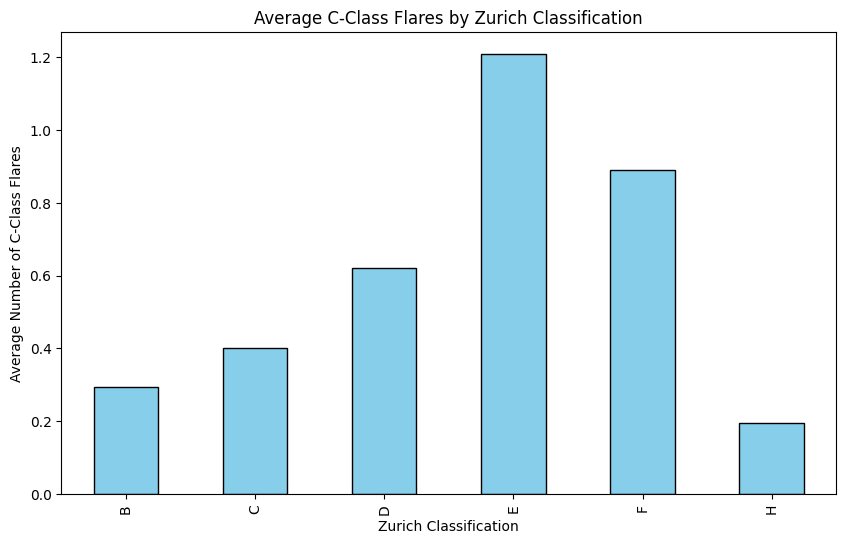

In [ ]:

#Imports
import matplotlib.pyplot as plt

#setting the figure size
plt.figure(figsize=(10, 6))

#Grouping, finding the mean, and plotting
df_cleaned.groupby('zurich_class')['c_class_flares'].mean().plot(kind='bar', color='skyblue', edgecolor='black')

#Adding overall labels for x-axis, y-axis, and title
plt.title('Average C-Class Flares by Zurich Classification')
plt.xlabel('Zurich Classification')
plt.ylabel('Average Number of C-Class Flares')



plt.show()

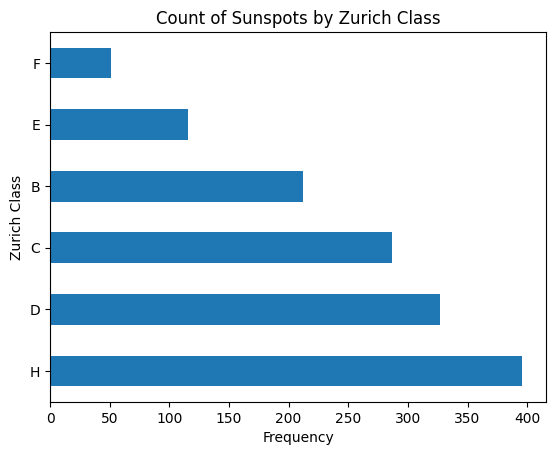

In [ ]:
zurich_counts = df['zurich_class'].value_counts()

zurich_counts.plot(kind='barh')
plt.title('Count of Sunspots by Zurich Class')
plt.xlabel('Frequency')
plt.ylabel('Zurich Class')
plt.show()

#How much spots fall under the Zurich Class

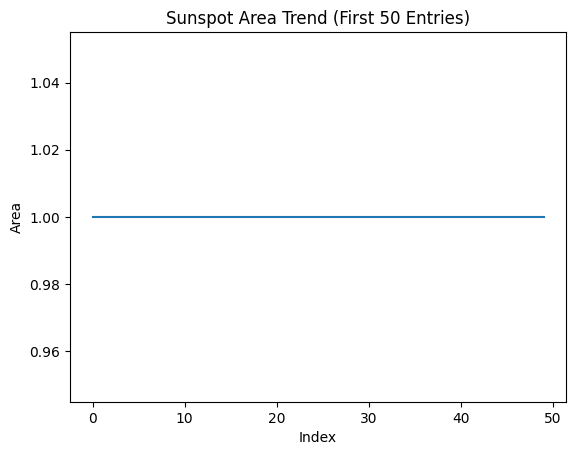

In [ ]:
plt.plot(df['area'].head(50))
plt.title('Sunspot Area Trend (First 50 Entries)')
plt.xlabel('Index')
plt.ylabel('Area')
plt.show()